In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df = pd.read_csv("height-weight.csv")

In [31]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


## Simple Linear Regression

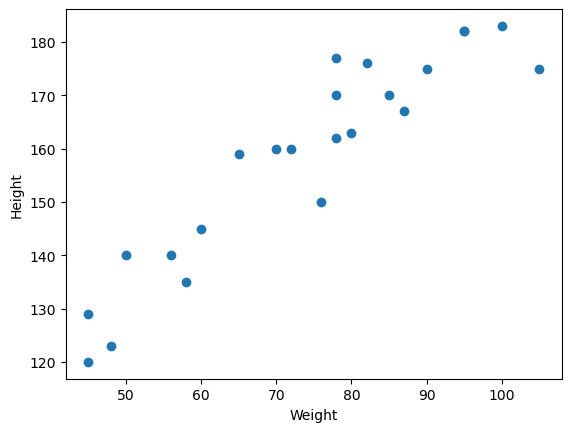

In [32]:
## scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()
            

In [33]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [34]:
import seaborn as sns
sns.pairplot(df)


In [35]:
## Independent and dependent features
X = df[['Weight']] # independent feature should be a dataframe. i.e we used double sqaure bracket [[]]
y = df['Height']   # the output should be in the series.

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [38]:
X_train.shape

(17, 1)

In [39]:
## Standardization 
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [41]:
X_test = scaler.transform(X_test)

In [42]:
## Linear Regression
from sklearn.linear_model import LinearRegression

In [43]:
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [44]:
## model is trained with train dataset. Now We can predict the value with test dataset
print("Coefficient or Slope: ", regression.coef_)
print("Intercept: ", regression.intercept_)

Coefficient or Slope:  [17.2982057]
Intercept:  156.47058823529412


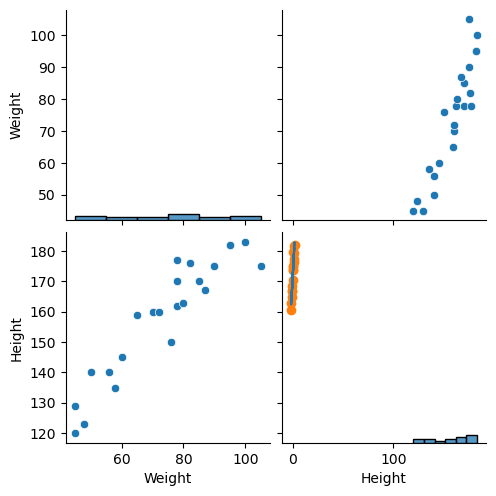

In [45]:
## plot Training data plot with best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))
plt.show()

In [46]:
## prediction for the test data
y_predict = regression.predict(X_test)
y_predict

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [47]:
## Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [48]:
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R square
### Formuls
### R^2 = 1 - SSR / SST
#### R^2 -> Co-efficient of determination
#### SSR -> Sum of square of residuals
#### SST -> Total sum of Squares


In [49]:
from sklearn.metrics import r2_score

In [50]:
score = r2_score(y_predict, y_test)
print(score)

0.7242334405003443


## Adjusted R^2
### Adjusted R^2 = 1 - [(1-R^2) * (n - 1) / (n - k - 1)]
#### where
#### R^2 - The R2 of the model, n - The number of observation, k - The number of predicted value

In [51]:
# display adjusted R-squared
1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

0.6552918006254305

In [52]:
## OLS linear regression
import statsmodels.api as sm

In [53]:
model = sm.OLS(y_train, X_train).fit()

In [54]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [55]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 31 Oct 2025   Prob (F-statistic):                       0.664
Time:                        17:21:09   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\manoj\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [56]:
## prediction for user/new data
regression.predict([[72]])
## weight - 72 | the predicted height is array([1401.94139895])
## why? the reason is standardization is not happen with the input 72

array([1401.94139895])

In [57]:
regression.predict(scaler.transform([[72]]))
## After applying the standardization to the input data
## the predicted height is array([155.97744705])

C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])